# K-Nearest Neighbors, Explained

## The story so far

Maya is deciding whether a new customer belongs to a known customer group. She does not want to write a long list of rules. Her idea is simple: find the most similar customers nearby and let their answers guide the new answer. That is the central idea of **K-Nearest Neighbors**, or **KNN**.

We will use the same idea twice: first to choose a class, and then to estimate a number. The important question throughout is: *which old examples are closest to this new example?*

## Journey

1. Build and look at labelled points.
2. Split old examples into training and test data.
3. Use nearby labels to classify a new point.
4. Inspect the actual neighbours.
5. Use nearby target numbers for regression.
6. Understand the important assumptions and mistakes.

## How to run this notebook

Run the cells from top to bottom using **Run All**. A markdown cell only explains the next step; a Python cell creates the data, model, or visual. If you run only one Python cell, earlier variables may not exist yet.

The first picture is the cell titled **The story, drawn before the algorithm**. To run only that cell, run the setup cell immediately before it first; that setup creates the shared `plt` plotting name.

## Setup: importing tools

**What:** import the KNN models, plotting tool, and data generator.

**Why here:** Python only knows a library function after we import it.

**What breaks if skipped:** Python raises `NameError`, meaning it cannot find the name we typed.

In [11]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.datasets import make_blobs, make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## The story, drawn before the algorithm

Maya has one new customer. The two numbers describe that customer on a map: feature 1 is the horizontal position and feature 2 is the vertical position. The coloured customers are older cases whose group is already known.

The five lines are the important part of the picture. They connect Maya's new customer to the five closest old customers. Three neighbours are blue and two are orange, so the majority vote is blue.

This is KNN before we use any scikit-learn model: **find nearby examples, look at their answers, and let the local majority decide.**

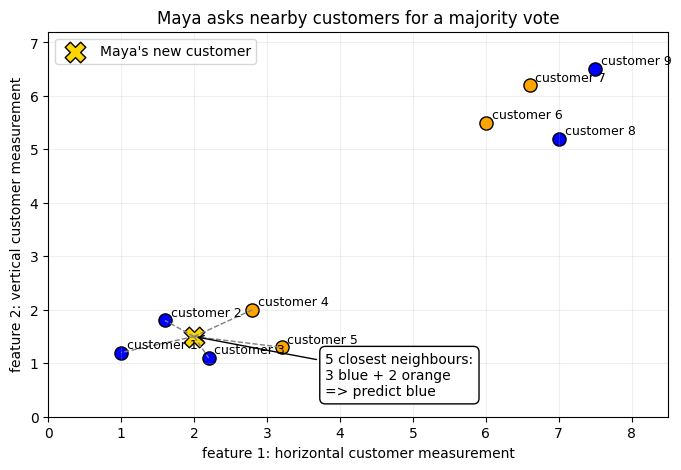

In [12]:
story_points = [
    (1.0, 1.2, 'blue'), (1.6, 1.8, 'blue'), (2.2, 1.1, 'blue'),
    (2.8, 2.0, 'orange'), (3.2, 1.3, 'orange'),
    (6.0, 5.5, 'orange'), (6.6, 6.2, 'orange'),
    (7.0, 5.2, 'blue'), (7.5, 6.5, 'blue')
]
new_customer = (2.0, 1.5)
nearest_indexes = [0, 1, 2, 3, 4]

plt.figure(figsize=(8, 5))
for index, (feature_1, feature_2, group) in enumerate(story_points):
    plt.scatter(feature_1, feature_2, c=group, s=90, edgecolor='black')
    plt.text(feature_1 + 0.08, feature_2 + 0.08, f'customer {index + 1}', fontsize=9)

for index in nearest_indexes:
    feature_1, feature_2, _ = story_points[index]
    plt.plot(
        [new_customer[0], feature_1],
        [new_customer[1], feature_2],
        color='gray', linestyle='--', linewidth=1
    )

plt.scatter(
    *new_customer, c='gold', edgecolor='black', marker='X', s=220,
    label='Maya\'s new customer'
)
plt.annotate(
    '5 closest neighbours:\n3 blue + 2 orange\n=> predict blue',
    xy=new_customer, xytext=(3.8, 0.4),
    arrowprops={'arrowstyle': '->', 'color': 'black'},
    bbox={'boxstyle': 'round,pad=0.4', 'facecolor': 'white', 'edgecolor': 'black'}
)
plt.xlabel('feature 1: horizontal customer measurement')
plt.ylabel('feature 2: vertical customer measurement')
plt.title('Maya asks nearby customers for a majority vote')
plt.xlim(0, 8.5)
plt.ylim(0, 7.2)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

### What the story visual teaches

The yellow `X` is the customer we need to classify. The dashed lines show the five neighbours KNN selected; points that are far away in the upper-right are ignored for this decision. Because three selected neighbours are blue and only two are orange, the predicted class is blue.

Later, `KNeighborsClassifier(n_neighbors=5)` performs this same process automatically. The hand-drawn picture comes first so that `n_neighbors=5`, distance, and majority vote have something concrete to refer to.

## 1. Make a small classification world

`make_blobs` creates groups of points for practice. Each row is one example. Each column is one feature. `y` is the answer attached to each row.

Syntax: `make_blobs(n_features=2, n_samples=1000, cluster_std=2, centers=2, random_state=1)`

- `n_features=2`: every point has two measurements, so we can draw it on an x/y chart.
- `n_samples=1000`: create 1,000 rows.
- `cluster_std=2`: control how spread out each group is. Larger means more overlap.
- `centers=2`: create two groups.
- `random_state=1`: use the same random data every time.

In [13]:
X, y = make_blobs(
    n_features=2,
    n_samples=1000,
    cluster_std=2,
    centers=2,
    random_state=1
)
print('X shape:', X.shape)
print('y shape:', y.shape)
print('first X row:', X[0])
print('first y value:', y[0])

X shape: (1000, 2)
y shape: (1000,)
first X row: [-4.45718554  4.57002551]
first y value: 0


### Reading the result

`X` has shape `(number_of_rows, number_of_features)`. Therefore `X.shape` should be `(1000, 2)`. `y` has one answer per row, so its shape is `(1000,)`. The rows line up: `X[0]` and `y[0]` describe the same example.

## Seeing the problem before naming the solution

`plt.scatter` draws one dot per row. `X[:, 0]` means: take every row and column 0. `X[:, 1]` means: take every row and column 1. The comma separates row selection from column selection. `c=y` colours dots by their known class.

This visual is useful because KNN depends on physical closeness. If a new point is surrounded mostly by class 1 points, KNN will probably choose class 1.

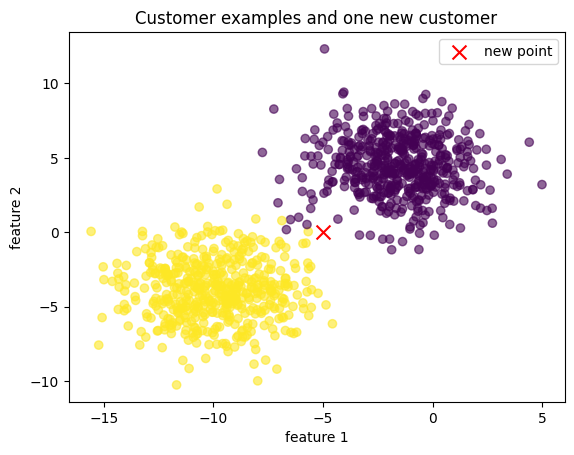

In [14]:
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, c=y)
plt.scatter(-5, 0, c='red', marker='x', s=100, label='new point')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('Customer examples and one new customer')
plt.legend()
plt.show()

### What to look at

The coloured dots form two groups. The red `x` is a new point with two feature values: `-5` and `0`. KNN does not invent a formula for this point. It asks which stored dots are closest to it.

Analogy: this is like routing a support ticket to the team that handled the most similar tickets. The analogy breaks down when the features use incompatible units; distance can then be misleading.

## 2. Split the examples: practice data versus exam data

Before training, we hide some rows. The training set is the examples KNN may look at. The test set is an unseen exam.

Syntax: `train_test_split(X, y, test_size=0.3, random_state=0)`

- `X, y`: split features and answers in the same way, so rows stay matched.
- `test_size=0.3`: reserve 30% for testing; 70% remains for training.
- `random_state=0`: make the split repeatable.
- The four outputs are features for training, features for testing, answers for training, and answers for testing.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(700, 2) (300, 2)
(700,) (300,)


## 3. Create and train a KNN classifier

`KNeighborsClassifier` is the classification version of KNN. Classification means the answer is a label such as `spam`/`not spam` or `0`/`1`.

`KNeighborsClassifier(n_neighbors=5)` means: when deciding a new label, inspect the five closest training rows. The number 5 is called `k`.

`.fit(X_train, y_train)` gives the model its reference examples. KNN is often called a lazy learner: it does very little calculation during `fit`; it keeps the training data so it can compare distances later.

In [16]:
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### Measuring correctly

`.score(X, y)` returns accuracy for this classifier: the fraction of rows predicted correctly. The important syntax detail is *which rows we pass*.

The scratch notebook used `classifier.score(X, y)`. That tests rows the model has already seen. It is useful as a quick sanity check, but it is not a fair estimate of future performance. We will use `X_test, y_test` for the honest score.

In [17]:
training_accuracy = classifier.score(X_train, y_train)
test_accuracy = classifier.score(X_test, y_test)
print('training accuracy:', training_accuracy)
print('test accuracy:', test_accuracy)

training accuracy: 0.9971428571428571
test accuracy: 1.0


## 4. Ask who the neighbours are

`classifier.kneighbors([[-5, 0]])` finds neighbours for one new row. The outer list matters: scikit-learn expects a table with shape `(number_of_rows, number_of_features)`, so one row still needs two pairs of brackets.

The result has two arrays: distances and positions. A small distance means a nearby row. A position is the row index inside the fitted training data.

In [18]:
distances, positions = classifier.kneighbors([[-5, 0]])
print('distances:', distances)
print('training-row positions:', positions)
print('neighbour labels:', y_train.iloc[positions[0]] if hasattr(y_train, 'iloc') else y_train[positions[0]])
print('prediction:', classifier.predict([[-5, 0]]))

distances: [[0.67827132 0.90025909 1.1140586  1.19193246 1.50207321]]
training-row positions: [[286 463 171 479 143]]
neighbour labels: [1 0 0 1 0]
prediction: [0]


### Why this prediction happens

KNN looks at the five labels returned for the five closest rows and chooses the majority label. `predict` returns the final label. `kneighbors` is for investigation: it lets us see the evidence behind the prediction.

Changing `k` changes the story. A very small `k` listens to a tiny local group and can be noisy. A large `k` listens to a broad group and can ignore a small but meaningful local pattern.

## Checkpoint

1. Why do we pass `X_test` to the final score instead of the full `X`?
2. If `n_neighbors=1`, how many training labels vote?
3. What does a very large distance tell us?

**Answers:** 1. Test rows simulate unseen future rows. 2. One row votes, so one noisy example can control the answer. 3. The new row is unlike the stored examples, so the prediction deserves caution.

## 5. KNN regression: predict a number

Classification chooses a label. Regression estimates a continuous number, such as price, delivery time, or temperature.

`make_regression` creates numeric targets. Here `n_features=1` means each row has one input feature. `noise=20` adds realistic variation around the hidden relationship.

The regression model uses the same neighbourhood idea, but averages the target values of nearby rows instead of taking a majority vote.

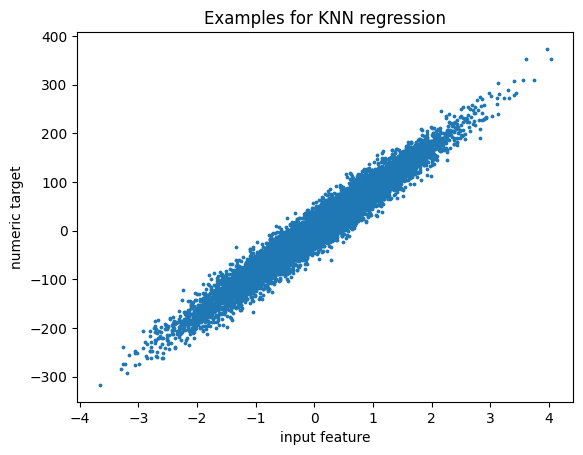

In [19]:
X_reg, y_reg = make_regression(
    n_features=1, noise=20, n_samples=10000, random_state=1
)
plt.scatter(X_reg, y_reg, s=3)
plt.xlabel('input feature')
plt.ylabel('numeric target')
plt.title('Examples for KNN regression')
plt.show()

### Create, train, and inspect the regressor

`KNeighborsRegressor(n_neighbors=3)` uses the three nearest rows. `.fit(X_reg, y_reg)` stores the examples. `.predict([[1]])` asks for the estimated target at input value 1. Again, `[[1]]` is a one-row, one-column table.

For a regressor, `.score()` is the coefficient of determination, called $R^2$, rather than classification accuracy. A score closer to 1 means the predictions explain more of the target variation; it can also be negative when the model is poor.

In [20]:
regressor = KNeighborsRegressor(n_neighbors=3)
regressor.fit(X_reg, y_reg)
print('training R^2:', regressor.score(X_reg, y_reg))
distances, positions = regressor.kneighbors([[1]])
neighbour_targets = y_reg[positions[0]]
prediction = regressor.predict([[1]])
print('neighbour targets:', neighbour_targets)
print('manual average:', neighbour_targets.mean())
print('KNN prediction:', prediction)

training R^2: 0.9657784708687274
neighbour targets: [81.98019188 51.59353389 62.51252132]
manual average: 65.36208236231441
KNN prediction: [65.36208236]


### Read the regression result

The manual average and the model prediction should match because regression KNN predicts the mean of the selected neighbours by default. The classifier used a majority vote; the regressor uses an average.

The scratch notebook manually added three target values and divided by 3. `neighbour_targets.mean()` expresses the same idea safely: it computes the average of however many neighbours the model actually selected.

## Important limitations

- **Scale matters:** KNN uses distance. A feature measured in thousands can overpower a feature measured in decimals. Scale features before using KNN when units differ.
- **Choice of k matters:** small `k` can overreact to noise; large `k` can smooth away useful local structure.
- **Prediction can be slow:** KNN keeps many rows and searches them when a prediction arrives. This is different from a compact formula.
- **Sparse regions are risky:** if a new row is far from every training row, its nearest neighbours may still be poor examples.
- **Do not trust training scores alone:** always measure on held-out data, ideally with cross-validation when comparing settings.

## Final cheat sheet

| Syntax | Plain English |
| --- | --- |
| `KNeighborsClassifier(n_neighbors=5)` | make a classifier that listens to 5 nearby rows |
| `KNeighborsRegressor(n_neighbors=3)` | make a regressor that averages 3 nearby rows |
| `.fit(X_train, y_train)` | store examples and their answers |
| `.predict(new_rows)` | produce answers for new rows |
| `.score(X_test, y_test)` | compare predictions with known answers |
| `.kneighbors(new_rows)` | show distances and positions of nearby training rows |
| `X[:, 0]` | every row from column 0 |
| `[[1]]` | one row containing one feature |
| `random_state=1` | make random generation repeatable |

If you remember only one thing: **KNN predicts from nearby examples, so the meaning of near, the choice of k, and the quality of the stored examples control the answer.**